# Config

In [1]:
import os

# Ruta a la que quieres mover el path
nueva_ruta = "/tmp/Repository/VRID_language_proyect/BERT"

# Cambiar el directorio actual
os.chdir(nueva_ruta)

# Confirmar que cambió
print("Directorio actual:", os.getcwd())

Directorio actual: /tmp/Repository/VRID_language_proyect/BERT


In [2]:
import pandas as pd
import os
from preprocess.preprocess import clean_text, check_deleted_expressions
from preprocess.translate import translator, gen_text_for_embedding, final_clean, detect_language
import time
import json
import numpy as np

# load and merge data  

In [204]:
path = "/tmp/ocde/data"
ocde_data = pd.read_excel(os.path.join(path, "data_150_random+all.xlsx"))
df = pd.read_csv(os.path.join(path, "data_translated_concat.csv"))

In [205]:
print(ocde_data.columns, df.columns)
# Cantidad de 'Código VRID' que están en ambos DataFrames
coinciden = df['Código VRID'].isin(ocde_data['Código VRID']).sum()

print(f"Número de 'Código VRID' de df que coinciden con ocde_data: {coinciden}")

Index(['Código Interno', 'IDTabla', 'Título', 'TituloIngles', 'Código VRID',
       'Valor Pesos', 'Tipo Proyecto', 'Estado', 'Clasificación',
       'Nombre Facultad', 'Nombre Departamento', 'Año Inicio',
       'Fecha Inicio.Fecha Inicio', 'Año Término Real', 'Fecha Término Real',
       'Rut', 'Datos Personales.Nombre Registral', 'Sexo', 'Horas Dedicación',
       'Tipo Investigador', 'Investigador Responsable   1=SI y 0=NO', 'Origen',
       'Tipo Contrato', 'Es Académico', 'Correo UdeC',
       'Facultad/Organismo del investigador', 'Carrera/Programa/Repartición',
       'Lidera(1=Lidera, 0=Asociado)', 'DisciplinaOCDEInformadaUdeC',
       'DisciplinaOCDEAjustada', 'IDDisciplinaOCDEAjustada',
       'LÍNEA DE INVESTIGACIÓN\nCategoríaAsignadaModelo',
       'IDCategoriaAsignada', 'UnidadAcademicaAsociada', 'AreaOCDE',
       'SubareaOCDE'],
      dtype='object') Index(['Código VRID', 'Interdisciplinario', 'Transdisciplinario', 'Título',
       'Keywords', 'Resumen', 'Facultad del P

In [206]:
# Eliminar todos los 'Código VRID' que estén repetidos
ocde_data_clean = ocde_data[~ocde_data['Código VRID'].duplicated(keep=False)]

# Añadir 'AreaOCDE' y 'SubareaOCDE' de ocde_data a df en base a 'Código VRID'
df = df.merge(ocde_data_clean[['Código VRID', 'AreaOCDE', 'SubareaOCDE']], how='inner')

In [207]:
df["AreaOCDE"].value_counts()

Ciencias Naturales             92
Ciencias Sociales              46
Ingeniería y Tecnología        41
Ciencias Médicas y de Salud    20
Humanidades                    19
Ciencias Agrícolas             12
Name: AreaOCDE, dtype: int64

In [208]:
# Save the final dataframe
df.to_csv(os.path.join(path, "data_ocde_merge.csv"), 
          index=False, 
          encoding="utf-8")

# 1) Similarity all data

### Functions

In [195]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [196]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
import numpy as np

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df

In [197]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    
    result = area1
    
    return result

def replace_ocde_codes(df, orig, new):
    df["AreaOCDE"] = df["AreaOCDE"].str.lower()
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE trad"] = df["AreaOCDE"].replace(orig[idx], new[idx])
    return df

In [198]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, preds):
    
    print("F1-score (macro):", f1_score(y, preds, average="macro"))
    print("Accuracy:", accuracy_score(y, preds))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


### eval sim

In [199]:
path = "/tmp/ocde/data"
df = pd.read_csv(os.path.join(path, "data_ocde_merge.csv"))

#Drop nan de ["AreaOCDE"]
df = df.dropna(subset=["AreaOCDE"]).reset_index(drop=True)
df["AreaOCDE"] = df["AreaOCDE"].str.lower()

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Lectura de codigos 
#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
X, _, _ = gen_dataset_select_cols_distance(df, cols = cols)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
emb_pubs = embed_texts(X, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [200]:
# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————

mapping = {
    "ciencias agrícolas": "agricultural sciences",
    "ciencias médicas y de salud": "medical and health sciences",
    "ciencias naturales": "natural sciences",
    "ciencias sociales": "social sciences",
    "humanidades": "humanities",
    "ingeniería y tecnología": "engineering and technology"
}

df["Area OCDE trad"] = df["AreaOCDE"].replace(mapping)
print(df["Area OCDE trad"].value_counts())

# 5) Clasificar cada publicación
df["clasificaciones"] = [
    classify_two_stage(vec, emb_ocde, ocde_keys, ocde_hierarchy, text)
    for vec, text in zip(emb_pubs, X)
]

df["clasificaciones"] = df["clasificaciones"].astype(str).str.lower()

natural sciences               92
social sciences                46
engineering and technology     41
medical and health sciences    20
humanities                     19
agricultural sciences          12
Name: Area OCDE trad, dtype: int64


Classes name: ['agricultural sciences' 'engineering and technology' 'humanities'
 'medical and health sciences' 'natural sciences' 'social sciences']
F1-score (macro): 0.5620548385114766
Accuracy: 0.6


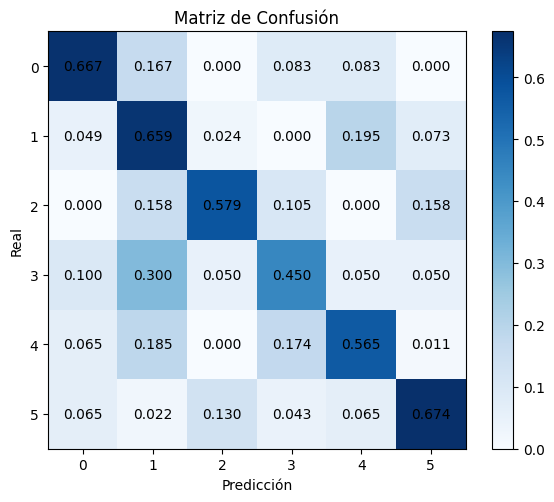

In [201]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df["Area OCDE trad"])
preds = le.transform(df["clasificaciones"])

print("Classes name:", le.classes_)
print_metrics(y, preds)

# 2) Split dataset

In [210]:
def to_serializable(obj):
    if hasattr(obj, "tolist"):
        return obj.tolist()
    return obj

In [211]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
import json

path = "/tmp/ocde/data"
df = pd.read_csv(os.path.join(path, "data_ocde_merge.csv"))
#Drop nan de ["AreaOCDE"]
df = df.dropna(subset=["AreaOCDE"]).reset_index(drop=True)
df["AreaOCDE"] = df["AreaOCDE"].str.lower()
# Traducción de categorías OCDE
mapping = {
    "ciencias agrícolas": "agricultural sciences",
    "ciencias médicas y de salud": "medical and health sciences",
    "ciencias naturales": "natural sciences",
    "ciencias sociales": "social sciences",
    "humanidades": "humanities",
    "ingeniería y tecnología": "engineering and technology"
}

df["Area OCDE trad"] = df["AreaOCDE"].replace(mapping)

le = LabelEncoder()
df["labels"] = le.fit_transform(df["Area OCDE trad"])

# Convertir a arrays
ids = df["Código VRID"].to_numpy()
labels = df["labels"].to_numpy()

# Train/Test split (ids y labels en paralelo)
idx_train, idx_test, y_train, y_test = train_test_split(
    ids,
    labels,
    test_size=0.2,
    random_state=7,
    stratify=labels
)

# Crear folds sobre train
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)

folds = []
for fold, (train_pos, val_pos) in enumerate(skf.split(idx_train, y_train)):
    train_ids = idx_train[train_pos]   # array de IDs
    val_ids = idx_train[val_pos]       # array de IDs
    folds.append(val_ids)

print("Test size:", len(idx_test))
print("Fold 0 - Val size:", len(folds[0]))

#Guardar index en diccionario
dataset_index = {
    "Train": idx_train,
    "Test": idx_test,
    "kfolds": folds 
}
filepath=os.path.join(path, "train_test_ids_3folds.json")

# Guardar
with open(filepath, "w", encoding="utf-8") as f:
    json.dump(dataset_index, f, default=to_serializable, indent=2, ensure_ascii=False)


Test size: 46
Fold 0 - Val size: 62


# 4) Similarity test

### Functions

In [132]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [133]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
import numpy as np

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df

In [134]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    
    result = area1
    
    return result

def replace_ocde_codes(df, orig, new):
    df["AreaOCDE"] = df["AreaOCDE"].str.lower()
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE trad"] = df["AreaOCDE"].replace(orig[idx], new[idx])
    return df

In [135]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, preds):
    
    print("F1-score (macro):", f1_score(y, preds, average="macro"))
    print("Accuracy:", accuracy_score(y, preds))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


### eval sim

In [136]:
def gen_dataset_select_cols(codes_vrid, df, cols, element_names=None):
    #Selección unicamente de elementos de df que se encuentren en codes_vrid
    df = df[df["Código VRID"].isin(codes_vrid)].copy()

    #Creación de index en función de orden de los datos
    df['idx'] = np.arange(0, df.shape[0])

    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df

In [137]:
path = "/tmp/ocde/data"
df = pd.read_csv(os.path.join(path, "data_ocde_merge.csv"))

#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/data"
filepath=os.path.join(path, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Drop nan de ["AreaOCDE"]
df = df.dropna(subset=["AreaOCDE"]).reset_index(drop=True)
df["AreaOCDE"] = df["AreaOCDE"].str.lower()

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Lectura de codigos 
#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "Depto_Persona_trad", "keywords_trad", "Resumen_trad"]
element_names=["Title:", "Department:", "keywords:", "abstract:"]

#Lectura de codigos 
codes_test = dataset_index["Test"]
X, _, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, element_names=element_names)


#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
emb_pubs = embed_texts(X, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [138]:
# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————

mapping = {
    "ciencias agrícolas": "agricultural sciences",
    "ciencias médicas y de salud": "medical and health sciences",
    "ciencias naturales": "natural sciences",
    "ciencias sociales": "social sciences",
    "humanidades": "humanities",
    "ingeniería y tecnología": "engineering and technology"
}

df_test["Area OCDE trad"] = df_test["AreaOCDE"].replace(mapping)
print(df_test["Area OCDE trad"].value_counts())

# 5) Clasificar cada publicación
df_test["clasificaciones"] = [
    classify_two_stage(vec, emb_ocde, ocde_keys, ocde_hierarchy, text)
    for vec, text in zip(emb_pubs, X)
]

df_test["clasificaciones"] = df_test["clasificaciones"].astype(str).str.lower()

natural sciences               18
social sciences                 9
engineering and technology      8
humanities                      4
medical and health sciences     4
agricultural sciences           3
Name: Area OCDE trad, dtype: int64


Classes name: ['agricultural sciences' 'engineering and technology' 'humanities'
 'medical and health sciences' 'natural sciences' 'social sciences']
F1-score (macro): 0.5544566544566546
Accuracy: 0.6086956521739131


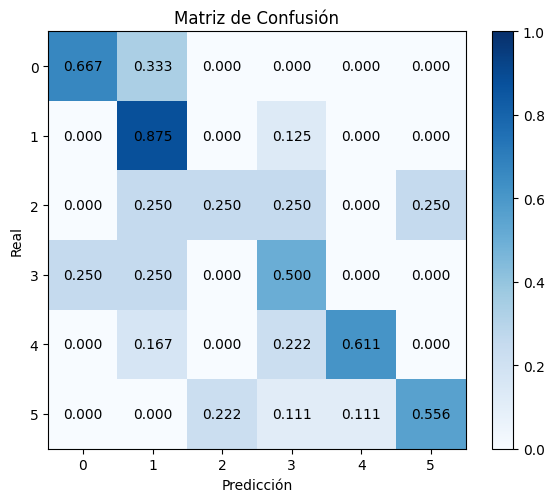

In [79]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df_test["Area OCDE trad"])
preds = le.transform(df_test["clasificaciones"])

print("Classes name:", le.classes_)
print_metrics(y, preds)

### Save

In [80]:
import mlflow
import git

#MLflow logging helper function
def safe_log_metric(name, value):
    try:
        if isinstance(value, (list, tuple, np.ndarray)):
            if np.size(value) == 1:
                value = float(np.array(value).item())
            else:
                raise ValueError("Métrica con más de un valor.")
        else:
            value = float(value)
        mlflow.log_metric(name, value)
    except Exception as e:
        print(f"⚠️ No se pudo loggear {name}: {e}")

def mlflow_ckeckpoint_sim(exp_info, extra_parms, preds, y_test, mode="server", mode_classification="binary"):
    
    if mode == "server":
        # Set backend store
        mlflow.set_tracking_uri("http://mlflow-server:5000")
        tracking_uri = mlflow.get_tracking_uri()
        print("Current tracking uri: {}".format(tracking_uri)) 
    
    elif mode == "local": 
        # Set backend store
        mlflow.set_tracking_uri(exp_info["tracking_path"])
        tracking_uri = mlflow.get_tracking_uri()
        print("Current tracking uri: {}".format(tracking_uri)) 

        # Verificar si existe experimento, si no crearlo
        experiment = mlflow.get_experiment_by_name(exp_info["exp_name"])

        if experiment is None:
            exp_id = mlflow.create_experiment(
                exp_info["exp_name"],
                artifact_location=exp_info["artifact_path"]
            )
            print(f"Experimento creado con ID: {exp_id}")
        else:
            exp_id = experiment.experiment_id
            print(f"Experimento ya existe con ID: {exp_id}")
    
    else: 
        print("Especificar modo de almacenamiento")
        return 0

    # Define el experimento (lo crea si no existe)
    mlflow.set_experiment(exp_info["exp_name"])
    with mlflow.start_run(run_name=extra_parms["Experiment_type"]):
        # Obtener commit actual
        repo = git.Repo(search_parent_directories=True)
        commit_hash = repo.head.object.hexsha

        #Guardar cm
        fname = f"cm.csv"
        cm = confusion_matrix(y_test, preds)
        np.savetxt(fname, cm, delimiter=",", fmt="%d")
        mlflow.log_artifact(fname, artifact_path="confusion_matrices")
        # Eliminar archivo local si no lo necesitas
        os.remove(fname)
        #Guardar métrica numérica
        safe_log_metric("test_f1_macro", f1_score(y_test, preds, average="macro"))
        safe_log_metric("test_accuracy", accuracy_score(y_test, preds))
        #Guardar parámetros del experimento
        for key, value in extra_parms.items():
            mlflow.log_param(key, value)
        
        #Guardar commit de git
        mlflow.log_param("git_commit", commit_hash)

    #end run
    mlflow.end_run()
    

In [81]:
exp_info = {
    'exp_name': "OCDE_sim_specter2_classification",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "Experiment_type": "similarity",
    "cols": cols,
    "model_base": BASE_MODEL,
}

mlflow_ckeckpoint_sim(exp_info,  extra_parms, preds, y, mode_classification="multiclass")

Current tracking uri: http://mlflow-server:5000
🏃 View run similarity at: http://mlflow-server:5000/#/experiments/12/runs/8b3eb128064c40558ea0c1c71f1e391c
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12


# 5) Similarity + classifier 

### Functions

In [116]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [117]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
import numpy as np

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df

In [118]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    
    result = area1
    
    return result

def replace_ocde_codes(df, orig, new):
    df["AreaOCDE"] = df["AreaOCDE"].str.lower()
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE trad"] = df["AreaOCDE"].replace(orig[idx], new[idx])
    return df

In [119]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, preds):
    
    print("F1-score (macro):", f1_score(y, preds, average="macro"))
    print("Accuracy:", accuracy_score(y, preds))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


### eval sim

In [139]:
def gen_dataset_select_cols(codes_vrid, df, cols, element_names=None):
    #Selección unicamente de elementos de df que se encuentren en codes_vrid
    df = df[df["Código VRID"].isin(codes_vrid)].copy()

    #Creación de index en función de orden de los datos
    df['idx'] = np.arange(0, df.shape[0])

    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df


In [140]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/data"
filepath=os.path.join(path, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_ocde_merge.csv")
df = pd.read_csv(filepath)
df = df.dropna(subset=["AreaOCDE"]).reset_index(drop=True)
df["AreaOCDE"] = df["AreaOCDE"].str.lower()

In [141]:
#del gen_dataset
#from utils.dataset import gen_dataset_select_cols
from models.specter import embed_texts
import numpy as np
from sklearn.preprocessing import LabelEncoder

mapping = {
    "ciencias agrícolas": "agricultural sciences",
    "ciencias médicas y de salud": "medical and health sciences",
    "ciencias naturales": "natural sciences",
    "ciencias sociales": "social sciences",
    "humanidades": "humanities",
    "ingeniería y tecnología": "engineering and technology"
}

df["Area OCDE trad"] = df["AreaOCDE"].replace(mapping)
print(df["Area OCDE trad"].value_counts())


#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "Depto_Persona_trad", "keywords_trad", "Resumen_trad"]
element_names=["Title:", "Department:", "keywords:", "abstract:"]

#Lectura de codigos 
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, element_names=element_names)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols)
df_decode = df_train[["idx", "Código VRID"]]


# Codificación de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 2) Calcular embeddings
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
X_train = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)

print(X_train.shape, X_test.shape)

natural sciences               92
social sciences                46
engineering and technology     41
medical and health sciences    20
humanities                     19
agricultural sciences          12
Name: Area OCDE trad, dtype: int64


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(184, 768) (46, 768)


In [143]:
# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)
#Generar embeddings
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [144]:
def sim_vectors(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    return sims

#Train
sim_train = []
for vec, text in zip(X_train, df_train["text_for_embedding_translated"]):
    sim_train.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
    
sim_train = np.array(sim_train)
print(sim_train.shape)
#Test
sim_test = []
for vec, text in zip(X_test, df_test["text_for_embedding_translated"]):
    sim_test.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
sim_test = np.array(sim_test)
print(sim_test.shape)

(184, 39)
(46, 39)


In [145]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, sim_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.57, 'std_test_score': 0.05}
RandomForestClassifier: {'mean_test_score': 0.53, 'std_test_score': 0.11}
XGBClassifier: {'mean_test_score': 0.51, 'std_test_score': 0.12}
SVC: {'mean_test_score': 0.64, 'std_test_score': 0.09}


In [146]:
def eval_model(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  return results

LogisticRegression


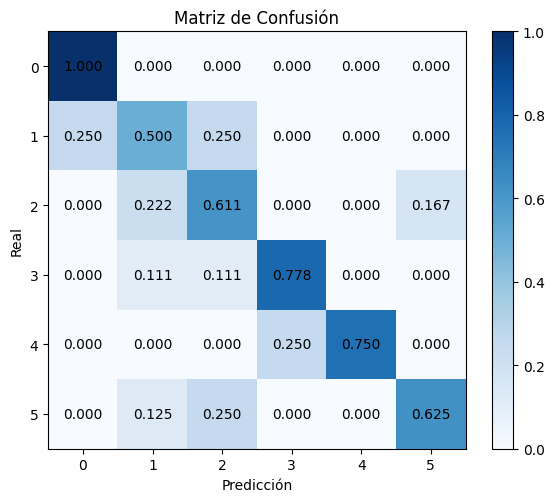

RandomForestClassifier


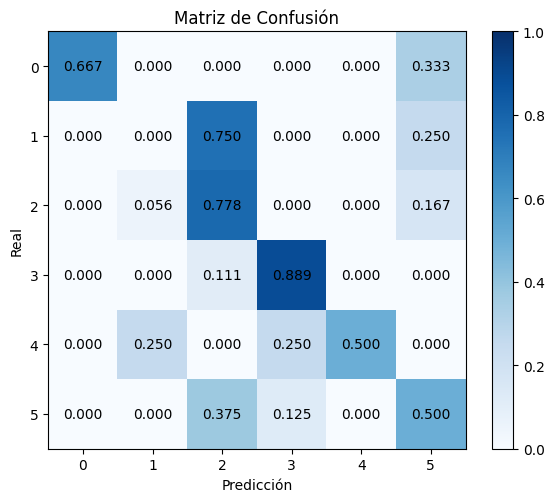

XGBClassifier


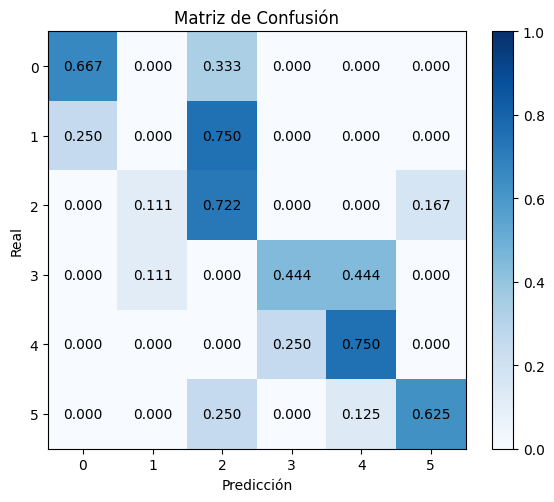

SVC


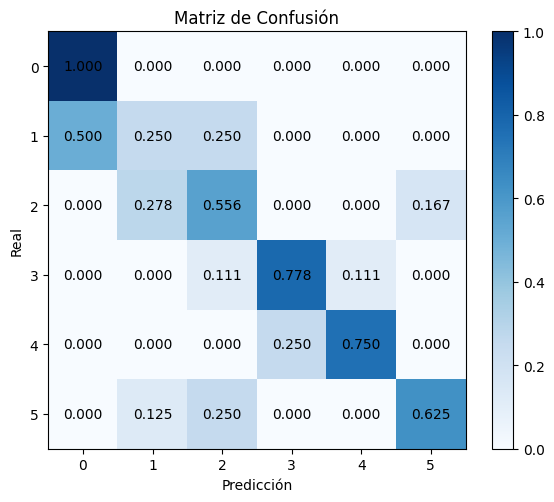

In [147]:
def print_cm(y, preds):

    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

def eval_model_print_cm(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  print_cm(y_test, preds)
  return results

# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model_print_cm(model, sim_test, y_test, lang_es)
    

In [ ]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, sim_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6739130434782609, 'f1_macro': 0.6938025210084033, 'cm': array([[ 3,  0,  0,  0,  0,  0],
       [ 1,  2,  1,  0,  0,  0],
       [ 0,  4, 11,  0,  0,  3],
       [ 0,  1,  1,  7,  0,  0],
       [ 0,  0,  0,  1,  3,  0],
       [ 0,  1,  2,  0,  0,  5]])}
RandomForestClassifier
{'accuracy': 0.6739130434782609, 'f1_macro': 0.5956354300385108, 'cm': array([[ 1,  0,  1,  0,  0,  1],
       [ 0,  1,  3,  0,  0,  0],
       [ 0,  0, 15,  0,  0,  3],
       [ 0,  0,  1,  8,  0,  0],
       [ 0,  1,  0,  1,  2,  0],
       [ 0,  0,  3,  1,  0,  4]])}
XGBClassifier
{'accuracy': 0.5869565217391305, 'f1_macro': 0.5109663234663234, 'cm': array([[ 2,  0,  1,  0,  0,  0],
       [ 1,  0,  3,  0,  0,  0],
       [ 0,  2, 13,  0,  0,  3],
       [ 0,  1,  0,  4,  4,  0],
       [ 0,  0,  0,  1,  3,  0],
       [ 0,  0,  2,  0,  1,  5]])}
SVC
{'accuracy': 0.6304347826086957, 'f1_macro': 0.6258912655971479, 'cm': array([[ 3,  0,  0,  0,  0,  0],
       [ 2,  1,  1,  0,

### Save

In [ ]:
exp_info = {
    'exp_name': "OCDE_sim_specter2_classification",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "Experiment_type": "similarity + ML"
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, extra_parms, sim_test, y_test, lang_es, mode_classification="multiclass")

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/09 17:21:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/12/runs/353a2a33e7884466848c9049260c60fc
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/09 17:22:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/12/runs/d6a1a4b7cf744a0fa94641d3283bff92
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/09 17:22:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/12/runs/40f5c5b932d4431ab7ef7b606a6c1357
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: SVC


2025/09/09 17:22:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/12/runs/030fd9e47cde4f198c54ad22105ac13a
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12


# 6) classifier + embeddings 

### Functions

In [3]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [4]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
import numpy as np

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df

In [5]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    
    result = area1
    
    return result

def replace_ocde_codes(df, orig, new):
    df["AreaOCDE"] = df["AreaOCDE"].str.lower()
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE trad"] = df["AreaOCDE"].replace(orig[idx], new[idx])
    return df

In [6]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, preds):
    
    print("F1-score (macro):", f1_score(y, preds, average="macro"))
    print("Accuracy:", accuracy_score(y, preds))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


## eval sim

In [7]:
def gen_dataset_select_cols(codes_vrid, df, cols, element_names=None):
    #Selección unicamente de elementos de df que se encuentren en codes_vrid
    df = df[df["Código VRID"].isin(codes_vrid)].copy()

    #Creación de index en función de orden de los datos
    df['idx'] = np.arange(0, df.shape[0])

    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df


In [8]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/data"
filepath=os.path.join(path, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_ocde_merge.csv")
df = pd.read_csv(filepath)
df = df.dropna(subset=["AreaOCDE"]).reset_index(drop=True)
df["AreaOCDE"] = df["AreaOCDE"].str.lower()

In [9]:
#del gen_dataset
#from utils.dataset import gen_dataset_select_cols
from models.specter import embed_texts
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "Depto_Persona_trad", "keywords_trad", "Resumen_trad"]
element_names=["Title:", "Department:", "keywords:", "abstract:"]

#Lectura de codigos 
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, element_names=element_names)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols)
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 2) Calcular embeddings
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
X_train = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)

print(X_train.shape, X_test.shape)

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(184, 768) (46, 768)


In [ ]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

In [11]:
def eval_model(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  return results

LogisticRegression


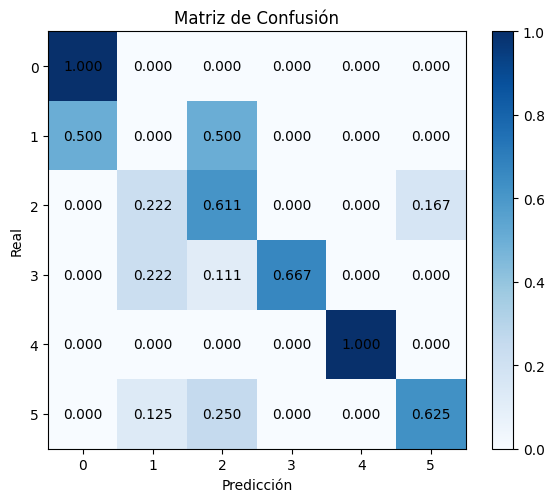

RandomForestClassifier


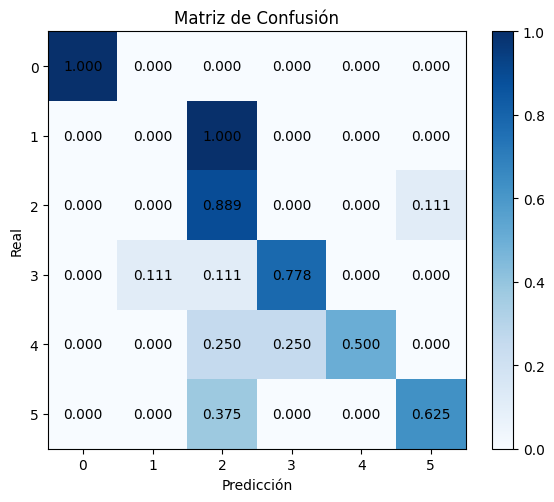

XGBClassifier


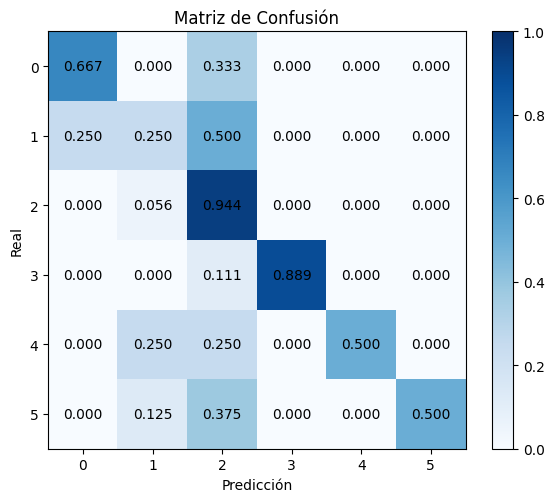

SVC


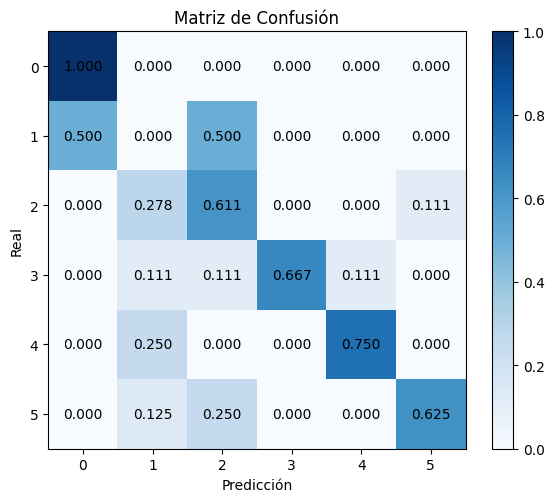

In [12]:
def print_cm(y, preds):

    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

def eval_model_print_cm(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  print_cm(y_test, preds)
  return results

# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model_print_cm(model, X_test, y_test, lang_es)
    

In [13]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6304347826086957, 'f1_macro': 0.6370098039215687, 'cm': array([[ 3,  0,  0,  0,  0,  0],
       [ 2,  0,  2,  0,  0,  0],
       [ 0,  4, 11,  0,  0,  3],
       [ 0,  2,  1,  6,  0,  0],
       [ 0,  0,  0,  0,  4,  0],
       [ 0,  1,  2,  0,  0,  5]])}
RandomForestClassifier
{'accuracy': 0.717391304347826, 'f1_macro': 0.6501747986016112, 'cm': array([[ 3,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  0,  0,  0],
       [ 0,  0, 16,  0,  0,  2],
       [ 0,  1,  1,  7,  0,  0],
       [ 0,  0,  1,  1,  2,  0],
       [ 0,  0,  3,  0,  0,  5]])}
XGBClassifier
{'accuracy': 0.7391304347826086, 'f1_macro': 0.6636456908344733, 'cm': array([[ 2,  0,  1,  0,  0,  0],
       [ 1,  1,  2,  0,  0,  0],
       [ 0,  1, 17,  0,  0,  0],
       [ 0,  0,  1,  8,  0,  0],
       [ 0,  1,  1,  0,  2,  0],
       [ 0,  1,  3,  0,  0,  4]])}
SVC
{'accuracy': 0.6086956521739131, 'f1_macro': 0.6022875816993464, 'cm': array([[ 3,  0,  0,  0,  0,  0],
       [ 2,  0,  2,  0, 

## Save

In [14]:
exp_info = {
    'exp_name': "OCDE_sim_specter2_classification",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "Experiment_type": "embeddings + ML"
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, extra_parms, X_test, y_test, lang_es, mode_classification="multiclass")

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/09 17:18:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/12/runs/89be2d9ebd5a49418ad1654b919cf2ab
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/09 17:18:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/12/runs/c7f32aad9e41461e808d7f7622a87e5b
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/09 17:18:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/12/runs/fc18b9e2fddc4c118c10fb237ee196fc
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: SVC


2025/09/09 17:18:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/12/runs/16b2acb5d0cf462fbbeb48364219e6f1
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12


# 7) classifier + embedding + sim

### Functions

In [82]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [83]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
import numpy as np

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df

In [84]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    
    result = area1
    
    return result

def replace_ocde_codes(df, orig, new):
    df["AreaOCDE"] = df["AreaOCDE"].str.lower()
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE trad"] = df["AreaOCDE"].replace(orig[idx], new[idx])
    return df

In [85]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, preds):
    
    print("F1-score (macro):", f1_score(y, preds, average="macro"))
    print("Accuracy:", accuracy_score(y, preds))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


### eval sim

In [ ]:
def gen_dataset_select_cols(codes_vrid, df, cols, element_names=None):
    #Selección unicamente de elementos de df que se encuentren en codes_vrid
    df = df[df["Código VRID"].isin(codes_vrid)].copy()

    #Creación de index en función de orden de los datos
    df['idx'] = np.arange(0, df.shape[0])

    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df


In [ ]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/data"
filepath=os.path.join(path, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_ocde_merge.csv")
df = pd.read_csv(filepath)
df = df.dropna(subset=["AreaOCDE"]).reset_index(drop=True)
df["AreaOCDE"] = df["AreaOCDE"].str.lower()

In [100]:
#del gen_dataset
#from utils.dataset import gen_dataset_select_cols
from models.specter import embed_texts
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "Depto_Persona_trad", "keywords_trad", "Resumen_trad"]
element_names=["Title:", "Department:", "keywords:", "abstract:"]

#Lectura de codigos 
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, element_names=element_names)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols)
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 2) Calcular embeddings
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
X_train = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)

print(X_train.shape, X_test.shape)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(184, 768) (46, 768)


In [101]:
# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)
#Generar embeddings
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [102]:
def sim_vectors(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    return sims

#Train
sim_train = []
for vec, text in zip(X_train, df_train["text_for_embedding_translated"]):
    sim_train.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
    
sim_train = np.array(sim_train)
print(sim_train.shape)
#Test
sim_test = []
for vec, text in zip(X_test, df_test["text_for_embedding_translated"]):
    sim_test.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
sim_test = np.array(sim_test)
print(sim_test.shape)

(184, 39)
(46, 39)


In [103]:
#Concatenate sim and X
X_train = np.concatenate((X_train, sim_train), axis=1)
X_test = np.concatenate((X_test, sim_test), axis=1)
print(X_train.shape, X_test.shape)

#Scale using standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(184, 807) (46, 807)


In [104]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.56, 'std_test_score': 0.06}
RandomForestClassifier: {'mean_test_score': 0.62, 'std_test_score': 0.06}
XGBClassifier: {'mean_test_score': 0.53, 'std_test_score': 0.1}
SVC: {'mean_test_score': 0.55, 'std_test_score': 0.06}


In [105]:
def eval_model(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  return results

LogisticRegression


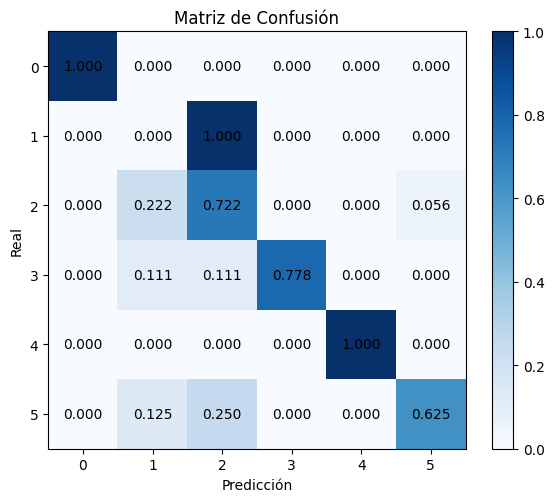

RandomForestClassifier


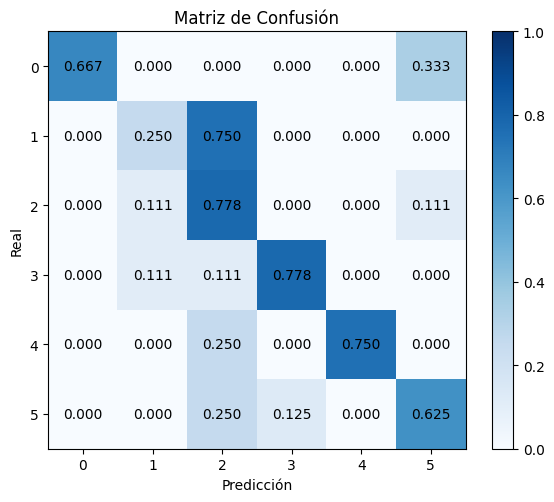

XGBClassifier


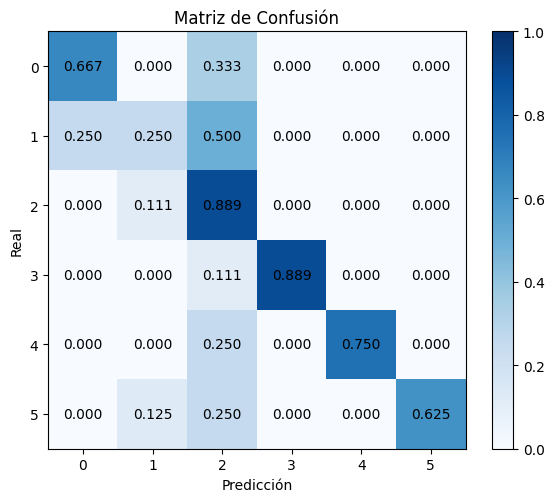

SVC


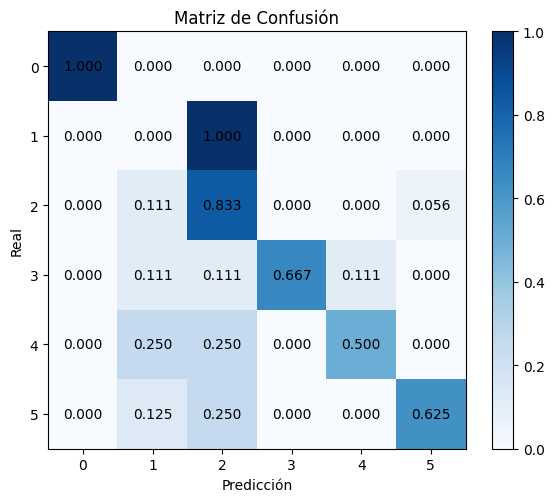

In [106]:
def print_cm(y, preds):

    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

def eval_model_print_cm(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  print_cm(y_test, preds)
  return results

# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model_print_cm(model, X_test, y_test, lang_es)
    

In [107]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6956521739130435, 'f1_macro': 0.712249373433584, 'cm': array([[ 3,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  0,  0,  0],
       [ 0,  4, 13,  0,  0,  1],
       [ 0,  1,  1,  7,  0,  0],
       [ 0,  0,  0,  0,  4,  0],
       [ 0,  1,  2,  0,  0,  5]])}
RandomForestClassifier
{'accuracy': 0.6956521739130435, 'f1_macro': 0.6789368311427135, 'cm': array([[ 2,  0,  0,  0,  0,  1],
       [ 0,  1,  3,  0,  0,  0],
       [ 0,  2, 14,  0,  0,  2],
       [ 0,  1,  1,  7,  0,  0],
       [ 0,  0,  1,  0,  3,  0],
       [ 0,  0,  2,  1,  0,  5]])}
XGBClassifier
{'accuracy': 0.7608695652173914, 'f1_macro': 0.7107840947510963, 'cm': array([[ 2,  0,  1,  0,  0,  0],
       [ 1,  1,  2,  0,  0,  0],
       [ 0,  2, 16,  0,  0,  0],
       [ 0,  0,  1,  8,  0,  0],
       [ 0,  0,  1,  0,  3,  0],
       [ 0,  1,  2,  0,  0,  5]])}
SVC
{'accuracy': 0.6739130434782609, 'f1_macro': 0.6362369337979096, 'cm': array([[ 3,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  0, 

### Save

In [108]:
from pipelines.ML_pipeline_skp import mlflow_ckeckpoint

exp_info = {
    'exp_name': "OCDE_sim_specter2_classification",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "Experiment_type": "similarity + embedding + ML",
    "scaler": "StandardScaler",
    "cols": cols,
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, extra_parms, X_test, y_test, lang_es, mode_classification="multiclass")

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/09 18:12:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/12/runs/c2b92f26e4a74718a6f553c6f0001abe
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/09 18:12:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/12/runs/b01f7e357bbf4aeaa77552a60c233d3f
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/09 18:13:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/12/runs/e219bb493922412f9729ea91cb17bf36
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: SVC


2025/09/09 18:13:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/12/runs/bc14c00191414b798040e86db6cd8b81
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12


# 8) TF-IDF + classifier

### Functions

In [3]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [4]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
import numpy as np

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df

In [5]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    
    result = area1
    
    return result

def replace_ocde_codes(df, orig, new):
    df["AreaOCDE"] = df["AreaOCDE"].str.lower()
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE trad"] = df["AreaOCDE"].replace(orig[idx], new[idx])
    return df

In [6]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, preds):
    
    print("F1-score (macro):", f1_score(y, preds, average="macro"))
    print("Accuracy:", accuracy_score(y, preds))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


## eval

In [7]:
def gen_dataset_select_cols(codes_vrid, df, cols, element_names=None):
    #Selección unicamente de elementos de df que se encuentren en codes_vrid
    df = df[df["Código VRID"].isin(codes_vrid)].copy()

    #Creación de index en función de orden de los datos
    df['idx'] = np.arange(0, df.shape[0])

    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["AreaOCDE"].to_list()
    return X, y, df


In [8]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/ocde/data"
filepath=os.path.join(path, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "data_ocde_merge.csv")
df = pd.read_csv(filepath)
df = df.dropna(subset=["AreaOCDE"]).reset_index(drop=True)
df["AreaOCDE"] = df["AreaOCDE"].str.lower()

In [20]:
#del gen_dataset
#from utils.dataset import gen_dataset_select_cols
from models.TIFD import gen_TFID_vectors
from models.specter import embed_texts
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "Depto_Persona_trad", "keywords_trad", "Resumen_trad"]
element_names=["Title:", "Department:", "keywords:", "abstract:"]

#Lectura de codigos 
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, element_names=element_names)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols)
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 2) Calcular vectores TFID
X_train, X_test = gen_TFID_vectors(X_train, X_test)

print(X_train.shape, X_test.shape)

(184, 7787) (46, 7787)


In [21]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.37, 'std_test_score': 0.07}
RandomForestClassifier: {'mean_test_score': 0.31, 'std_test_score': 0.07}
XGBClassifier: {'mean_test_score': 0.34, 'std_test_score': 0.09}
SVC: {'mean_test_score': 0.38, 'std_test_score': 0.05}


In [22]:
def eval_model(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  return results

LogisticRegression


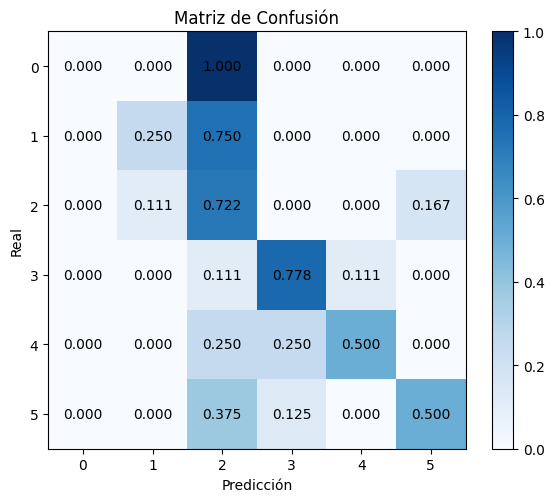

RandomForestClassifier


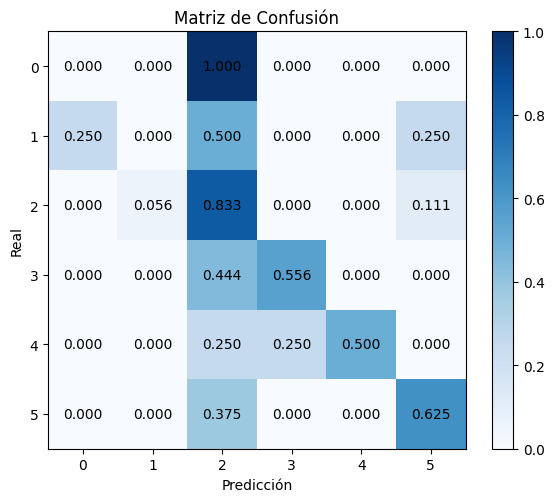

XGBClassifier


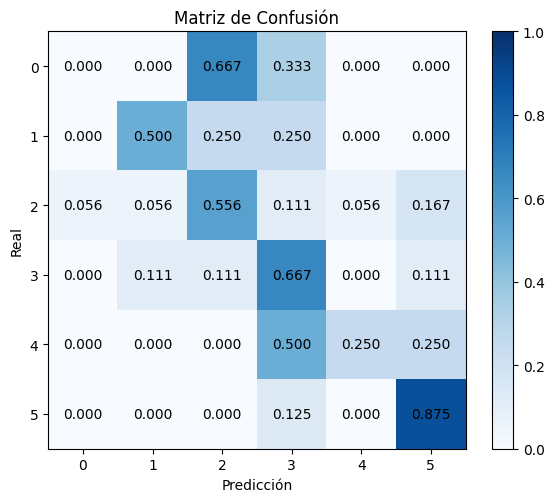

SVC


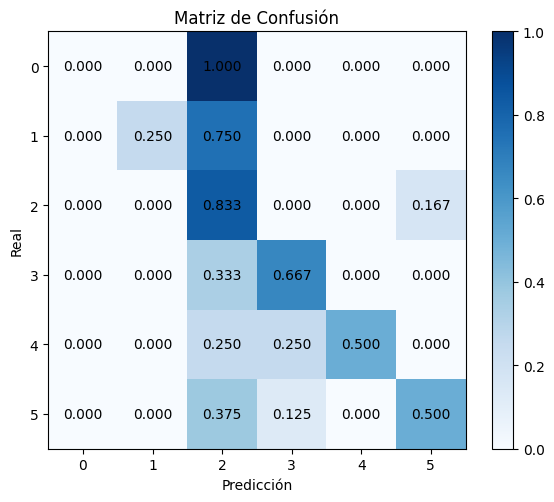

['ciencias agrícolas' 'ciencias médicas y de salud' 'ciencias naturales'
 'ciencias sociales' 'humanidades' 'ingeniería y tecnología']


In [23]:
def print_cm(y, preds):

    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

def eval_model_print_cm(best_model, X_test, y_test, lang_es):
  results = {}
  preds = best_model.predict(X_test)
  cm = confusion_matrix(y_test, preds)
  #f1_es, f1_en, cm_es, cm_en = metrics_lang(y_test, preds, lang_es)
  #t_n, f_p, f_n, t_p = cm()
  results = {
      'accuracy': accuracy_score(y_test, preds),
      'f1_macro': f1_score(y_test, preds, zero_division=0, average="macro"),
      'cm': cm,
      #'f1_es': f1_es,
      #'f1_en': f1_en,
      #'cm_es': cm_es,
      #'cm_en': cm_en
  }
  print_cm(y_test, preds)
  return results

# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model_print_cm(model, X_test, y_test, lang_es)

print(le.classes_)

In [24]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.5869565217391305, 'f1_macro': 0.46455026455026455, 'cm': array([[ 0,  0,  3,  0,  0,  0],
       [ 0,  1,  3,  0,  0,  0],
       [ 0,  2, 13,  0,  0,  3],
       [ 0,  0,  1,  7,  1,  0],
       [ 0,  0,  1,  1,  2,  0],
       [ 0,  0,  3,  1,  0,  4]])}
RandomForestClassifier
{'accuracy': 0.5869565217391305, 'f1_macro': 0.4350845410628019, 'cm': array([[ 0,  0,  3,  0,  0,  0],
       [ 1,  0,  2,  0,  0,  1],
       [ 0,  1, 15,  0,  0,  2],
       [ 0,  0,  4,  5,  0,  0],
       [ 0,  0,  1,  1,  2,  0],
       [ 0,  0,  3,  0,  0,  5]])}
XGBClassifier
{'accuracy': 0.5652173913043478, 'f1_macro': 0.45063131313131316, 'cm': array([[ 0,  0,  2,  1,  0,  0],
       [ 0,  2,  1,  1,  0,  0],
       [ 1,  1, 10,  2,  1,  3],
       [ 0,  1,  1,  6,  0,  1],
       [ 0,  0,  0,  2,  1,  1],
       [ 0,  0,  0,  1,  0,  7]])}
SVC
{'accuracy': 0.6086956521739131, 'f1_macro': 0.4930093776641091, 'cm': array([[ 0,  0,  3,  0,  0,  0],
       [ 0,  1,  3,  

### Save

In [25]:
exp_info = {
    'exp_name': "OCDE_sim_specter2_classification",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "Experiment_type": "TF-IDF + ML",
    "classes": le.classes_.tolist(),
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, extra_parms, X_test, y_test, lang_es, mode_classification="multiclass")

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/09 20:52:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/12/runs/3fbccce77989432aa8600afc21bb2025
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/09 20:52:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/12/runs/632352b032bd45f38983cab1bb3baa15
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/09 20:52:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/12/runs/eacc3217e22a4f37abb93c31dab0d18d
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12
📝 Registrando modelo en MLflow: SVC


2025/09/09 20:52:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/12/runs/9fe1637577674e979de6e2b1ea0ee68b
🧪 View experiment at: http://mlflow-server:5000/#/experiments/12


In [26]:
from collections import Counter
print(Counter(y_test))

Counter({2: 18, 3: 9, 5: 8, 4: 4, 1: 4, 0: 3})


In [29]:
print(le.classes_)

['ciencias agrícolas' 'ciencias médicas y de salud' 'ciencias naturales'
 'ciencias sociales' 'humanidades' 'ingeniería y tecnología']


In [28]:
df_test["AreaOCDE"].value_counts()

ciencias naturales             18
ciencias sociales               9
ingeniería y tecnología         8
humanidades                     4
ciencias médicas y de salud     4
ciencias agrícolas              3
Name: AreaOCDE, dtype: int64